# Downloads Library and Dependensi

In [6]:
!pip install tensorflow
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install pydot

# Import Library

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydot

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

# Import Data and Preprocessing

In [5]:
train_dir = 'E:/JST/TA/dataset/train'
val_dir = 'E:/JST/TA/dataset/val'
test_dir = 'E:/JST/TA/dataset/test'

In [6]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=180,
    zoom_range=0.2
)
val_test_gen = ImageDataGenerator(rescale=1./255)

In [7]:
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(100,100),
    class_mode='categorical',
    shuffle=True
)

val_data = val_test_gen.flow_from_directory(
    val_dir,
    target_size=(100,100),
    class_mode='categorical',
    shuffle=True
)

test_data = val_test_gen.flow_from_directory(
    test_dir,
    target_size=(100,100),
    class_mode='categorical',
    shuffle=False
)

Found 400 images belonging to 5 classes.
Found 50 images belonging to 5 classes.


Found 50 images belonging to 5 classes.


# Model Spesification

In [9]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(100, 100, 3)),
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.4),
    
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.4),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])

model.summary()

model.compile(loss = 'categorical_crossentropy', optimizer=RMSprop(learning_rate=0.001), metrics=['accuracy'])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 98, 98, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 98, 98, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 49, 49, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 49, 49, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 47, 47, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 47, 47, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 152,741 (596.64 KB)

 Trainable params: 152,133 (594.27 KB)

 Non-trainable params: 608 (2.38 KB)

# Training Model

In [10]:
history = model.fit(
            train_data,
            validation_data=val_data, 
            epochs=100)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.2425 - loss: 2.6150 - val_accuracy: 0.2000 - val_loss: 1.6124
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 408ms/step - accuracy: 0.3450 - loss: 2.0510 - val_accuracy: 0.2000 - val_loss: 1.6844
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 388ms/step - accuracy: 0.3625 - loss: 1.9295 - val_accuracy: 0.2000 - val_loss: 1.7169
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 371ms/step - accuracy: 0.2925 - loss: 1.9779 - val_accuracy: 0.2000 - val_loss: 1.7821
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 361ms/step - accuracy: 0.3500 - loss: 1.7071 - val_accuracy: 0.2000 - val_loss: 1.9904
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 333ms/step - accuracy: 0.3975 - loss: 1.6760 - val_accuracy: 0.2000 - val_loss: 2.0665
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 376ms/step - accuracy: 0.3875 - loss: 1.5559 - val_accuracy: 0.2000 - val_loss: 2.1523
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 371ms/step - accuracy: 0.3775 - loss: 1.5627 - val_accura

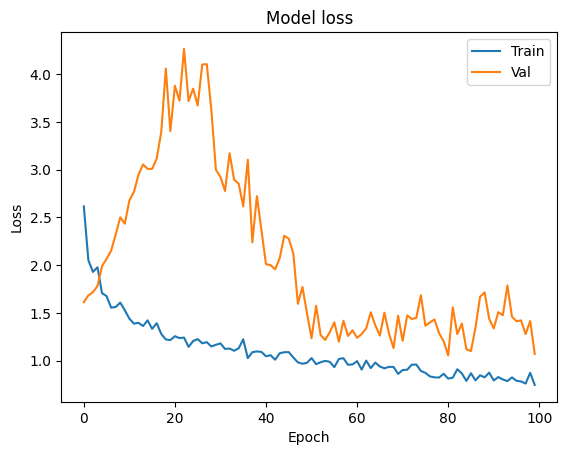

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

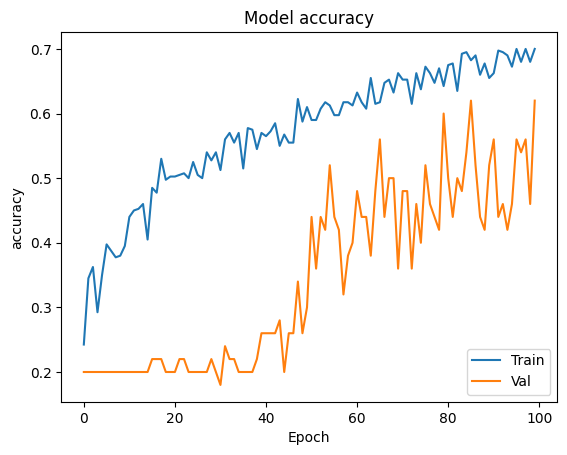

In [12]:
acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
plt.plot(history.history[acc_key])
val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc'
plt.plot(history.history[val_acc_key])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

# Testing Model

In [13]:
y_test = test_data.labels

In [15]:
y_test

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4], dtype=int32)

In [16]:
y_pred = np.argmax(model.predict(test_data), axis=-1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 923ms/step


In [17]:
accuracy_score(y_test, y_pred)

0.76

In [18]:
confusion_matrix(y_test, y_pred)

array([[ 6,  2,  2,  0,  0],
       [ 0,  8,  1,  0,  1],
       [ 0,  0,  7,  2,  1],
       [ 0,  2,  1,  7,  0],
       [ 0,  0,  0,  0, 10]])

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.60      0.75        10
           1       0.67      0.80      0.73        10
           2       0.64      0.70      0.67        10
           3       0.78      0.70      0.74        10
           4       0.83      1.00      0.91        10

    accuracy                           0.76        50
   macro avg       0.78      0.76      0.76        50
weighted avg       0.78      0.76      0.76        50



## save model architectur picture as png file

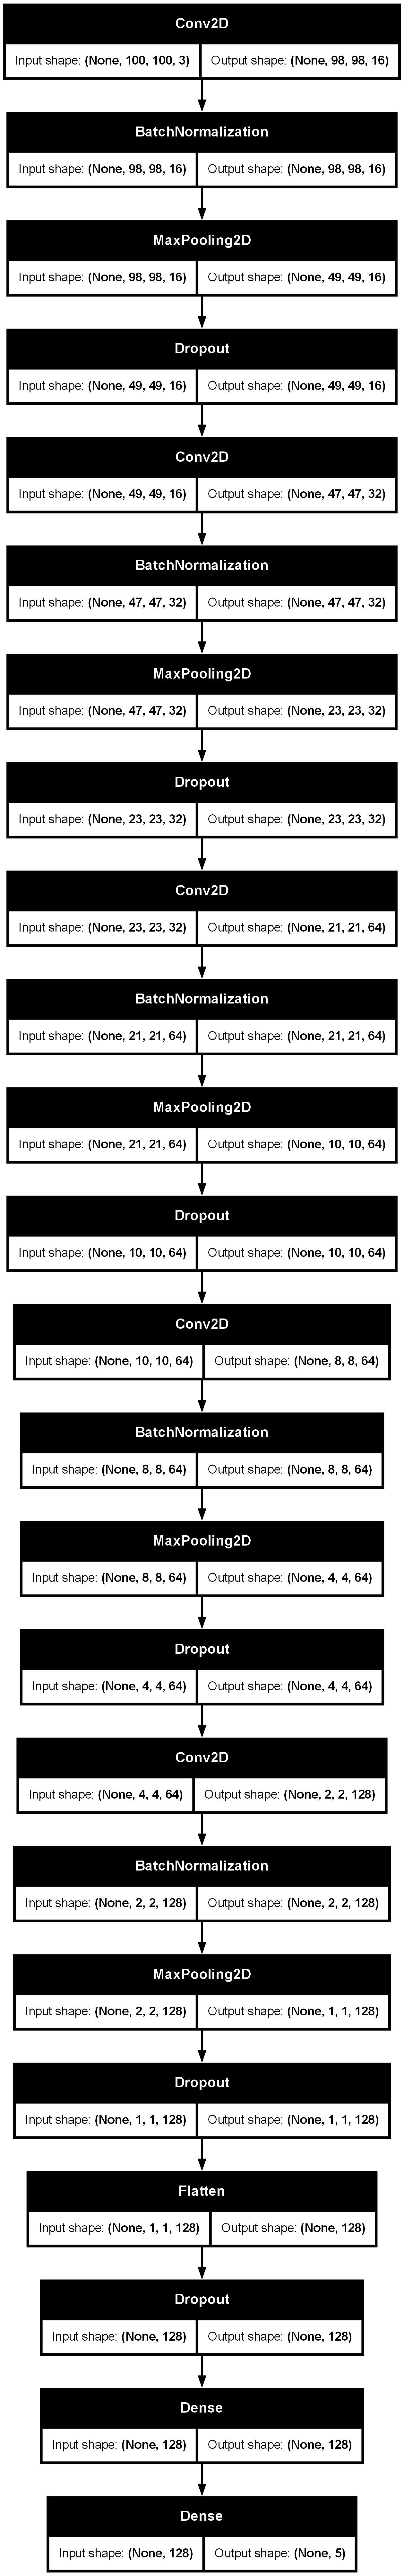

In [26]:
import os
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin'

dot_img_file = 'model_1.png'
tf.keras.utils.plot_model(model, to_file=dot_img_file, show_shapes=True)

# Save Model

In [27]:
#save architecture as json and weight as h5
model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)
# serialize weights to HDF5
model.save_weights("model.weights.h5")